# Semantic Plagiarism Detection System
### Using Pretrained Transformers + Neural Classifier (DNN)

**Objective:** Detect whether two text passages are plagiarized using semantic similarity.

In [1]:
# Install required libraries
# !pip install sentence-transformers scikit-learn tensorflow pandas numpy matplotlib seaborn

In [2]:
# import sys
# !{sys.executable} -m pip install statsmodels seaborn scikit-learn sentence-transformers tensorflow --quiet

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score,
    precision_recall_curve, auc
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from statsmodels.stats.contingency_tables import mcnemar

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)
print("Libraries loaded ✓")

TensorFlow: 2.21.0
Libraries loaded ✓


---
## Load Dataset

The dataset contains pairs of texts (`source_text`, `plagiarized_text`) with binary labels:
- **1** = Plagiarized 
- **0** = Not Plagiarized 

In [6]:
df = pd.read_csv(r'D:\Computer Science\College Projects\ANLP\data\dataset.csv', index_col=0)
# Rename columns for clarity
df = df.rename(columns={'source_text': 'text1', 'plagiarized_text': 'text2'})
df['label'] = df['label'].astype(int)

print(f"Dataset shape: {df.shape}")
print(f"\nLabel distribution:")
print(df['label'].value_counts().rename({0: 'Not Plagiarised', 1: 'Plagiarised'}))
df.head(5)

Dataset shape: (370, 3)

Label distribution:
label
Plagiarised        187
Not Plagiarised    183
Name: count, dtype: int64


,text1,text2,label
0,Researchers have discovered a new species of b...,Scientists have found a previously unknown but...,1
1,The moon orbits the Earth in approximately 27....,Our natural satellite takes around 27.3 days t...,1
2,Water is composed of two hydrogen atoms and on...,H2O consists of 2 hydrogen atoms and 1 oxygen ...,1
3,The history of Rome dates back to 753 BC.,Rome has a long history that can be traced bac...,1
4,Pluto was once considered the ninth planet in ...,"In the past, Pluto was classified as the ninth...",1


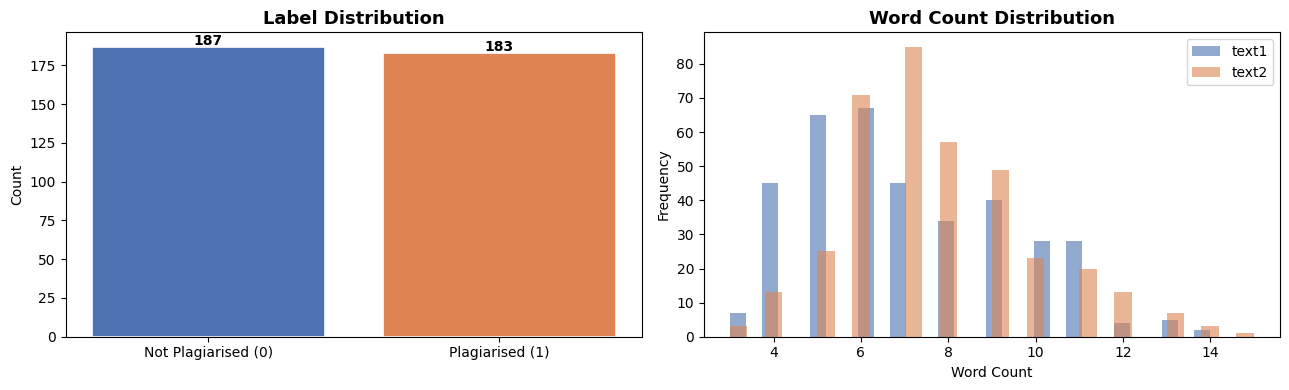

Avg text1 length: 7.0 words | Avg text2 length: 7.7 words


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Label distribution
counts = df['label'].value_counts()
axes[0].bar(['Not Plagiarised (0)', 'Plagiarised (1)'], counts.values,
            color=['#4C72B0', '#DD8452'], edgecolor='white', linewidth=1.2)
axes[0].set_title('Label Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Text length distribution
df['len1'] = df['text1'].str.split().str.len()
df['len2'] = df['text2'].str.split().str.len()
axes[1].hist(df['len1'], bins=30, alpha=0.6, label='text1', color='#4C72B0')
axes[1].hist(df['len2'], bins=30, alpha=0.6, label='text2', color='#DD8452')
axes[1].set_title('Word Count Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Avg text1 length: {df['len1'].mean():.1f} words | Avg text2 length: {df['len2'].mean():.1f} words")

---
## Text Preprocessing

We apply:
- Lowercase
- Remove extra whitespace

In [8]:
def preprocess(text: str) -> str:
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text1'] = df['text1'].apply(preprocess)
df['text2'] = df['text2'].apply(preprocess)

print("Sample after preprocessing:")
print(f"  text1: {df['text1'].iloc[0]}")
print(f"  text2: {df['text2'].iloc[0]}")
print(f"  label: {df['label'].iloc[0]}")

Sample after preprocessing:
  text1: researchers have discovered a new species of butterfly in the amazon rainforest.
  text2: scientists have found a previously unknown butterfly species in the amazon jungle.
  label: 1


---
## Sentence Embeddings (Transfer Learning)

We use `all-mpnet-base-v2` from `sentence-transformers`

In [9]:
print("Loading sentence transformer model...")
encoder = SentenceTransformer('all-mpnet-base-v2')

texts1 = df['text1'].tolist()
texts2 = df['text2'].tolist()

print("Encoding text1...")
emb1 = encoder.encode(texts1, show_progress_bar=True, batch_size=32)
print("Encoding text2...")
emb2 = encoder.encode(texts2, show_progress_bar=True, batch_size=32)

print(f"\nEmbedding shape per text: {emb1.shape}  (samples × 768 dimensions)")

Loading sentence transformer model...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1247.89it/s]


Encoding text1...


Batches: 100%|██████████| 12/12 [00:13<00:00,  1.12s/it]


Encoding text2...


Batches: 100%|██████████| 12/12 [00:09<00:00,  1.28it/s]


Embedding shape per text: (370, 768)  (samples × 768 dimensions)


---
## Feature Engineering

For each text pair we construct a rich feature vector:

| Feature | Shape | Captures |
|---|---|---|
| `emb1` | 768 | Absolute semantics of text1 |
| `emb2` | 768 | Absolute semantics of text2 |
| `\|emb1 - emb2\|` | 768 | Dimension-wise deviation |
| `emb1 * emb2` | 768 | Element-wise interaction |
| Cosine similarity | 1 | Overall directional similarity |

**Total feature size: 768×4 + 1 = 3073**

> The absolute difference highlights *where* the embeddings differ, element-wise product captures interaction effects, and cosine similarity gives a holistic score.

In [10]:
def build_features(e1: np.ndarray, e2: np.ndarray) -> np.ndarray:
    abs_diff = np.abs(e1 - e2)                                    # (N, 768)
    mult     = e1 * e2                                            # (N, 768)
    cos      = np.array([
        cos_sim([e1[i]], [e2[i]])[0][0] for i in range(len(e1))
    ]).reshape(-1, 1)                                             # (N, 1)
    return np.hstack([e1, e2, abs_diff, mult, cos])               # (N, 3073)

X = build_features(emb1, emb2)
y = df['label'].values

print(f"Feature matrix shape: {X.shape}")
print(f"Label vector shape:   {y.shape}")
print(f"Feature breakdown: 768 (emb1) + 768 (emb2) + 768 (|diff|) + 768 (mult) + 1 (cosine) = {X.shape[1]}")

Feature matrix shape: (370, 3073)
Label vector shape:   (370,)
Feature breakdown: 768 (emb1) + 768 (emb2) + 768 (|diff|) + 768 (mult) + 1 (cosine) = 3073


---
## Train / Validation / Test Split

We use a **70 / 15 / 15** stratified split to preserve the label ratio across all sets.

In [11]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.15/0.85, random_state=42, stratify=y_trainval
)

print(f"Train:      {X_train.shape[0]} samples  ({y_train.mean()*100:.1f}% plagiarised)")
print(f"Validation: {X_val.shape[0]} samples  ({y_val.mean()*100:.1f}% plagiarised)")
print(f"Test:       {X_test.shape[0]} samples  ({y_test.mean()*100:.1f}% plagiarised)")

# Feature scaling
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)
print("\nFeatures scaled with StandardScaler ✓")

Train:      258 samples  (50.8% plagiarised)
Validation: 56 samples  (50.0% plagiarised)
Test:       56 samples  (50.0% plagiarised)

Features scaled with StandardScaler ✓


---
## DNN Classifier

Architecture:
```
Input (3073) → Dense(512, ReLU) → BN → Dropout(0.3)
             → Dense(256, ReLU) → BN → Dropout(0.2)
             → Dense(128, ReLU) → Dropout(0.2)
             → Dense(1, Sigmoid)
```

- **BatchNormalization** stabilises training
- **Dropout** prevents overfitting on the small dataset
- **Sigmoid** output → probability of plagiarism

In [12]:
def build_model(input_dim: int) -> Sequential:
    m = Sequential([
        Dense(512, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(0.3),

        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),

        Dense(128, activation='relu'),
        Dropout(0.2),

        Dense(1, activation='sigmoid')
    ], name='PlagiarismDNN')

    m.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return m

model = build_model(X_train_s.shape[1])
model.summary()

Model: "PlagiarismDNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,741,313 (6.64 MB)

 Trainable params: 1,739,777 (6.64 MB)

 Non-trainable params: 1,536 (6.00 KB)

---
## Training

In [13]:
weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight = dict(enumerate(weights))

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

history = model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=60,
    batch_size=16,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 68ms/step - accuracy: 0.8023 - loss: 0.4310 - val_accuracy: 0.9286 - val_loss: 0.1719 - learning_rate: 0.0010
Epoch 2/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9806 - loss: 0.0922 - val_accuracy: 0.9643 - val_loss: 0.1442 - learning_rate: 0.0010
Epoch 3/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9884 - loss: 0.0436 - val_accuracy: 0.9464 - val_loss: 0.1554 - learning_rate: 0.0010
Epoch 4/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9961 - loss: 0.0200 - val_accuracy: 0.9464 - val_loss: 0.1541 - learning_rate: 0.0010
Epoch 5/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 1.0000 - loss: 0.0100 - val_accuracy: 0.9464 - val_loss: 0.1565 - learning_rate: 0.0010
Epoch 6/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 1.0000 - loss: 0.0089 - val_accuracy: 0.9464 - val_loss: 0.1576 - learning_rate: 0.0010
Epoch 7/60
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 0.0066
Epoch 7: 

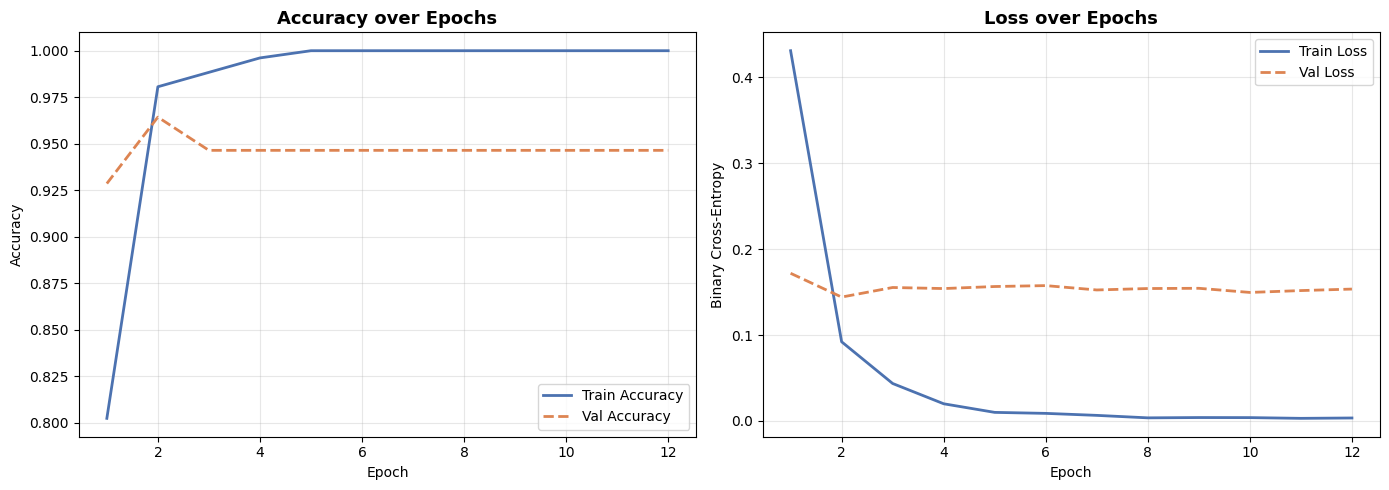

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_ran = range(1, len(history.history['accuracy']) + 1)

axes[0].plot(epochs_ran, history.history['accuracy'],     label='Train Accuracy', color='#4C72B0', lw=2)
axes[0].plot(epochs_ran, history.history['val_accuracy'], label='Val Accuracy',   color='#DD8452', lw=2, linestyle='--')
axes[0].set_title('Accuracy over Epochs', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_ran, history.history['loss'],     label='Train Loss', color='#4C72B0', lw=2)
axes[1].plot(epochs_ran, history.history['val_loss'], label='Val Loss',   color='#DD8452', lw=2, linestyle='--')
axes[1].set_title('Loss over Epochs', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Binary Cross-Entropy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Evaluation

In [15]:
y_prob = model.predict(X_test_s).flatten()

for thr in [0.5, 0.6, 0.67]:
    y_pred_thr = (y_prob >= thr).astype(int)
    print("=" * 55)
    print(f"  DNN — Test Set Results  (threshold = {thr})")
    print("=" * 55)
    print(f"  Accuracy : {accuracy_score(y_test, y_pred_thr)*100:.2f}%")
    print(f"  F1 Score : {f1_score(y_test, y_pred_thr)*100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_thr,
                                target_names=['Not Plagiarised', 'Plagiarised']))

y_pred = (y_prob >= 0.67).astype(int)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
  DNN — Test Set Results  (threshold = 0.5)
  Accuracy : 92.86%
  F1 Score : 93.33%

Classification Report:
                 precision    recall  f1-score   support

Not Plagiarised       1.00      0.86      0.92        28
    Plagiarised       0.88      1.00      0.93        28

       accuracy                           0.93        56
      macro avg       0.94      0.93      0.93        56
   weighted avg       0.94      0.93      0.93        56

  DNN — Test Set Results  (threshold = 0.6)
  Accuracy : 92.86%
  F1 Score : 93.10%

Classification Report:
                 precision    recall  f1-score   support

Not Plagiarised       0.96      0.89      0.93        28
    Plagiarised       0.90      0.96      0.93        28

       accuracy                           0.93        56
      macro avg       0.93      0.93      0.93        56
   weighted avg       0.93      0.93      0.93        56

  DNN — Test Set Results  (threshold = 0.67)
  Accuracy

### Confusion matrix + PR curve + AUPRC

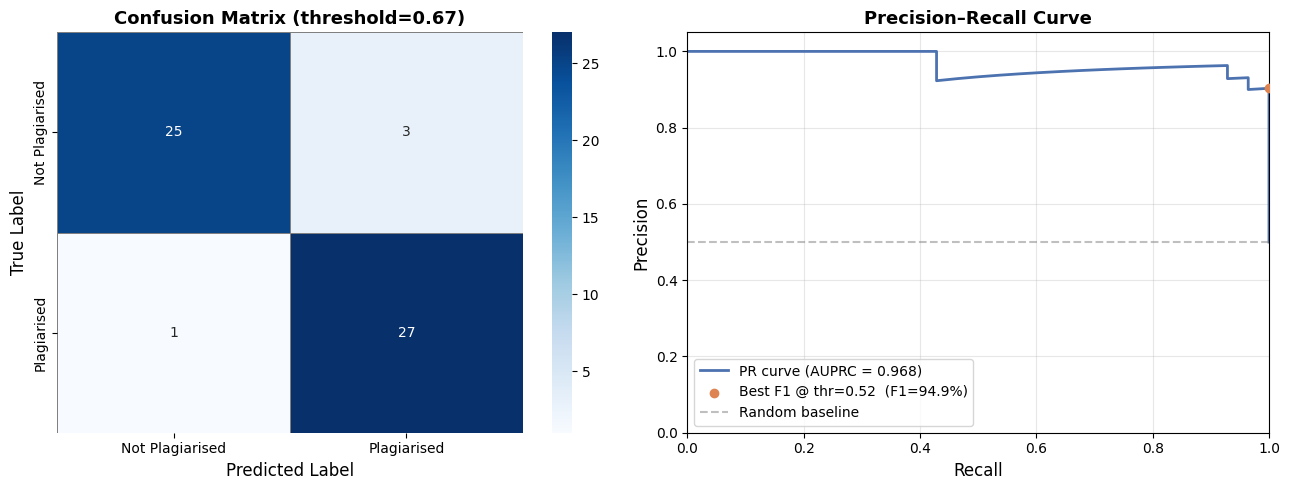

AUPRC (threshold-independent): 0.9679
Optimal threshold: 0.5163  →  Best F1: 94.92%

Confusion (threshold=0.67):
  True Negatives: 25  |  False Positives: 3
  False Negatives: 1  |  True Positives: 27


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Confusion matrix (threshold=0.67) ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Plagiarised', 'Plagiarised'],
            yticklabels=['Not Plagiarised', 'Plagiarised'],
            linewidths=0.5, linecolor='grey', ax=axes[0])
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_title('Confusion Matrix (threshold=0.67)', fontsize=13, fontweight='bold')

# --- Precision-Recall curve ---
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
auprc = auc(recalls, precisions)

# Find optimal threshold (max F1)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx  = np.argmax(f1_scores)
best_thr  = thresholds[best_idx]

axes[1].plot(recalls, precisions, color='#4C72B0', lw=2, label=f'PR curve (AUPRC = {auprc:.3f})')
axes[1].scatter(recalls[best_idx], precisions[best_idx], color='#DD8452', zorder=5,
                label=f'Best F1 @ thr={best_thr:.2f}  (F1={f1_scores[best_idx]*100:.1f}%)')
axes[1].axhline(y=sum(y_test)/len(y_test), color='grey', linestyle='--', alpha=0.5, label='Random baseline')
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision–Recall Curve', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)
axes[1].set_xlim([0, 1]); axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('pr_curve.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"AUPRC (threshold-independent): {auprc:.4f}")
print(f"Optimal threshold: {best_thr:.4f}  →  Best F1: {f1_scores[best_idx]*100:.2f}%")

tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion (threshold=0.67):")
print(f"  True Negatives: {tn}  |  False Positives: {fp}")
print(f"  False Negatives: {fn}  |  True Positives: {tp}")

---
## Baseline: TF-IDF + Logistic Regression


In [17]:
X_raw = pd.DataFrame({'text1': df['text1'], 'text2': df['text2']})

idx_all = np.arange(len(df))
idx_trainval, idx_test_b = train_test_split(idx_all, test_size=0.15, random_state=42, stratify=y)
idx_train_b, idx_val_b   = train_test_split(idx_trainval, test_size=0.15/0.85, random_state=42,
                                             stratify=y[idx_trainval])

def combined_text(df_in, idx):
    return (df_in['text1'].iloc[idx] + ' [SEP] ' + df_in['text2'].iloc[idx]).tolist()

train_texts = combined_text(X_raw, idx_train_b)
test_texts  = combined_text(X_raw, idx_test_b)
y_train_b   = y[idx_train_b]
y_test_b    = y[idx_test_b]

tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=10000, sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(train_texts)
X_test_tfidf  = tfidf.transform(test_texts)

lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_tfidf, y_train_b)
y_pred_lr = lr.predict(X_test_tfidf)

print("=" * 50)
print("  Baseline — TF-IDF + Logistic Regression")
print("=" * 50)
print(f"  Accuracy : {accuracy_score(y_test_b, y_pred_lr)*100:.2f}%")
print(f"  F1 Score : {f1_score(y_test_b, y_pred_lr)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test_b, y_pred_lr, target_names=['Not Plagiarised', 'Plagiarised']))

  Baseline — TF-IDF + Logistic Regression
  Accuracy : 89.29%
  F1 Score : 89.29%

Classification Report:
                 precision    recall  f1-score   support

Not Plagiarised       0.89      0.89      0.89        28
    Plagiarised       0.89      0.89      0.89        28

       accuracy                           0.89        56
      macro avg       0.89      0.89      0.89        56
   weighted avg       0.89      0.89      0.89        56



### Model Comparison Chart

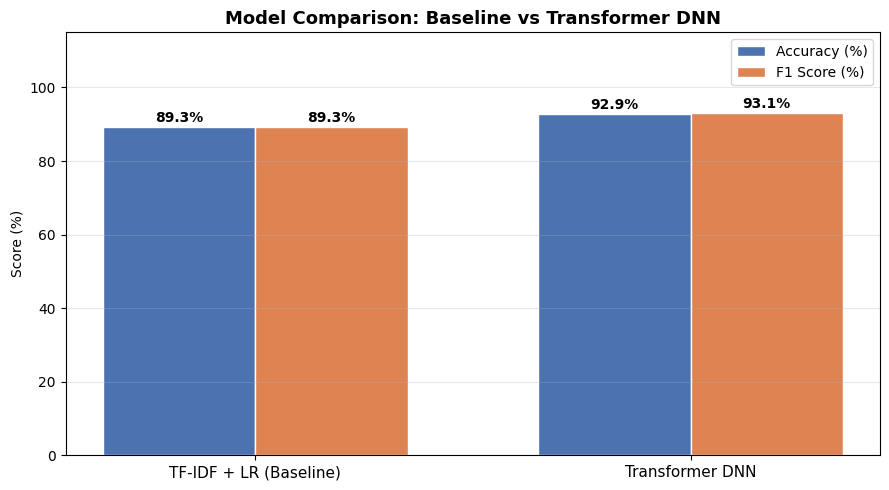


Metric            TF-IDF+LR  Transformer DNN   Improvement
----------------------------------------------------------
Accuracy             89.29%           92.86%        +3.57%
F1 Score             89.29%           93.10%        +3.82%


In [18]:
dnn_acc = accuracy_score(y_test_b, y_pred) * 100
dnn_f1  = f1_score(y_test_b, y_pred)       * 100
lr_acc  = accuracy_score(y_test_b, y_pred_lr) * 100
lr_f1   = f1_score(y_test_b, y_pred_lr)       * 100

models   = ['TF-IDF + LR (Baseline)', 'Transformer DNN']
acc_vals = [lr_acc, dnn_acc]
f1_vals  = [lr_f1,  dnn_f1]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, acc_vals, width, label='Accuracy (%)', color='#4C72B0', edgecolor='white')
bars2 = ax.bar(x + width/2, f1_vals,  width, label='F1 Score (%)', color='#DD8452', edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_ylim(0, 115)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylabel('Score (%)')
ax.set_title('Model Comparison: Baseline vs Transformer DNN', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\n{'Metric':<12} {'TF-IDF+LR':>14} {'Transformer DNN':>16} {'Improvement':>13}")
print("-" * 58)
print(f"{'Accuracy':<12} {lr_acc:>13.2f}% {dnn_acc:>15.2f}% {dnn_acc-lr_acc:>+12.2f}%")
print(f"{'F1 Score':<12} {lr_f1:>13.2f}% {dnn_f1:>15.2f}% {dnn_f1-lr_f1:>+12.2f}%")

---
## Inference Demo

`predict_plagiarism` takes two raw texts and returns a prediction with confidence score.

In [19]:
def predict_plagiarism(text1: str, text2: str, threshold: float = 0.67) -> dict:
    # 1. Preprocess
    t1 = preprocess(text1)
    t2 = preprocess(text2)

    # 2. Embed — reshape to (1, 768) explicitly to guard against shape issues
    e1 = encoder.encode([t1]).reshape(1, -1)   # (1, 768)
    e2 = encoder.encode([t2]).reshape(1, -1)

    # 3. Features  → (1, 3073)
    feats = build_features(e1, e2)
    feats_scaled = scaler.transform(feats)

    # 4. Predict
    prob   = model.predict(feats_scaled, verbose=0)[0][0]
    label  = int(prob >= threshold)
    cosine = cos_sim(e1, e2)[0][0]

    return {
        'prediction': 'Plagiarised [!]' if label == 1 else 'Not Plagiarised [OK]',
        'confidence': f'{prob*100:.2f}%',
        'cosine_similarity': f'{cosine:.4f}',
        'raw_prob': prob
    }

In [20]:
examples = [
    {
        'name': '[1] Direct Copy',
        'text1': 'Climate change is causing glaciers to melt at an unprecedented rate.',
        'text2': 'Climate change is causing glaciers to melt at an unprecedented rate.'
    },
    {
        'name': '[2] Paraphrase',
        'text1': 'The stock market experienced a significant decline due to rising inflation.',
        'text2': 'Soaring inflation rates led to a major drop in stock market values.'
    },
    {
        'name': '[3] Completely Different',
        'text1': 'Photosynthesis allows plants to convert sunlight into chemical energy.',
        'text2': 'The French Revolution began in 1789 with the storming of the Bastille.'
    },
]

print("=" * 65)
print("            PLAGIARISM DETECTION — DEMO")
print("=" * 65)
for ex in examples:
    result = predict_plagiarism(ex['text1'], ex['text2'])
    print(f"\n{ex['name']}")
    print(f"  Text 1 : {ex['text1'][:70]}")
    print(f"  Text 2 : {ex['text2'][:70]}")
    print(f"  Result : {result['prediction']}")
    print(f"  Confidence      : {result['confidence']}")
    print(f"  Cosine Sim      : {result['cosine_similarity']}")
    print("-" * 65)

            PLAGIARISM DETECTION — DEMO

[1] Direct Copy
  Text 1 : Climate change is causing glaciers to melt at an unprecedented rate.
  Text 2 : Climate change is causing glaciers to melt at an unprecedented rate.
  Result : Plagiarised [!]
  Confidence      : 99.52%
  Cosine Sim      : 1.0000
-----------------------------------------------------------------

[2] Paraphrase
  Text 1 : The stock market experienced a significant decline due to rising infla
  Text 2 : Soaring inflation rates led to a major drop in stock market values.
  Result : Plagiarised [!]
  Confidence      : 75.60%
  Cosine Sim      : 0.9126
-----------------------------------------------------------------

[3] Completely Different
  Text 1 : Photosynthesis allows plants to convert sunlight into chemical energy.
  Text 2 : The French Revolution began in 1789 with the storming of the Bastille.
  Result : Plagiarised [!]
  Confidence      : 99.99%
  Cosine Sim      : 0.2037
-----------------------------------------

---
## Save & Summary

In [21]:
import pickle

model.save('plagiarism_dnn.keras')

with open('feature_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model saved  -> plagiarism_dnn.keras")
print("Scaler saved -> feature_scaler.pkl")
print()
print("=" * 40)
print("  FINAL SUMMARY")
print("=" * 40)

print(f"  Transformer-DNN (seed=42, thr=0.67)")
print(f"    Accuracy : {dnn_acc:.2f}%  |  F1: {dnn_f1:.2f}%")

print(f"  Baseline (TF-IDF+LR)")
print(f"    Accuracy : {lr_acc:.2f}%  |  F1: {lr_f1:.2f}%")

Model saved  -> plagiarism_dnn.keras
Scaler saved -> feature_scaler.pkl

  FINAL SUMMARY
  Transformer-DNN (seed=42, thr=0.67)
    Accuracy : 92.86%  |  F1: 93.10%
  Baseline (TF-IDF+LR)
    Accuracy : 89.29%  |  F1: 89.29%
